# Healthcare Fraud Detection

## Business Question

> _What patterns most reliably identify fraudulent insurance claims?_

## Dataset

> Sourced from [Kaggle](https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset/data), this dataset comprises 10,000 simulated healthcare insurance claims that model real-world fraud scenarios. It includes a range of patient, provider, and financial attributes.

In [311]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Load Data

In [312]:
fraud_df = pd.read_csv("healthcare_fraud_detection.csv")

## Raw Data Overview

In [313]:
df = fraud_df.copy()
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 10,000 rows x 20 columns


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [314]:
df.info()
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  str    
 1   Claim_ID                               10000 non-null  str    
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  str    
 4   Diagnosis_Code                         10000 non-null  str    
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   str    
 9   Claim_Submission_Date                  10000 non-null  str    
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Number_of_Clai

In [315]:
print(f"\nFraud breakdown:\n{df['Is_Fraud'].value_counts()}")
print(f"\nFraud rate: {df['Is_Fraud'].mean():.2%}")


Fraud breakdown:
Is_Fraud
0    9171
1     829
Name: count, dtype: int64

Fraud rate: 8.29%


## Clean Data

In [316]:
df["Claim_Submission_Date"] = pd.to_datetime(df["Claim_Submission_Date"])

In [317]:
df["Insurance_Type"] = df["Insurance_Type"].fillna("Unknown")
df["Provider_Specialty"] = df["Provider_Specialty"].fillna("Unknown")

In [318]:
print(df["Prior_Visits_12m"].describe().round(3))
skewness = df["Prior_Visits_12m"].skew()
print(f"Skewness: {skewness:.2f}")

count    9650.000
mean        3.026
std         1.723
min         0.000
25%         2.000
50%         3.000
75%         4.000
max        12.000
Name: Prior_Visits_12m, dtype: float64
Skewness: 0.54


In [319]:
df["Prior_Visits_12m"] = df["Prior_Visits_12m"].fillna(
    df["Prior_Visits_12m"].median()
)

In [320]:
# Drop unnecessary ID and code columns
df.drop(columns=
        ["Provider_ID",
         "Claim_ID",
         "Diagnosis_Code",
         "Procedure_Code"],
        inplace=True)

In [321]:
df.head()

,Patient_Age,Patient_Gender,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,37,Male,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,21,Female,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,78,Female,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,65,Male,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,36,Male,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [322]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Patient_Age                            10000 non-null  int64         
 1   Patient_Gender                         10000 non-null  str           
 2   Claim_Amount                           10000 non-null  float64       
 3   Approved_Amount                        10000 non-null  float64       
 4   Insurance_Type                         10000 non-null  str           
 5   Claim_Submission_Date                  10000 non-null  datetime64[us]
 6   Days_Between_Service_and_Claim         10000 non-null  int64         
 7   Number_of_Claims_Per_Provider_Monthly  10000 non-null  int64         
 8   Provider_Specialty                     10000 non-null  str           
 9   Patient_State                          10000 non-null  str           
 10

## Feature Engineering

In [323]:
print(df["Number_of_Claims_Per_Provider_Monthly"].describe().round(3))

count    10000.000
mean        68.628
std         14.906
min         42.000
25%         60.000
50%         66.000
75%         72.000
max        144.000
Name: Number_of_Claims_Per_Provider_Monthly, dtype: float64


In [324]:
# Flag providers with more than 90 monthly claims
df["High_Volume_Claims_Flag"] = (
    df["Number_of_Claims_Per_Provider_Monthly"]
        .gt(90)
        .astype(int)
)

In [325]:
# Extract components from date column
df["Month"] = df["Claim_Submission_Date"].dt.month_name()
df["Quarter"] = "Q" + df["Claim_Submission_Date"].dt.quarter.astype(str)
df["Year"] = df["Claim_Submission_Date"].dt.year

In [326]:
# Measure the gap between what was claimed and what was approved 
df["Approved_Amt_Gap"] = df["Claim_Amount"] - df["Approved_Amount"]
df["Approved_Rate"] = (df["Approved_Amount"] / df["Claim_Amount"]).round(2)

In [327]:
# Fraud or legit
df["Fraud_Label"] = df["Is_Fraud"].map({1: "Fraud", 0: "Legitimate"})
df.head()

,Patient_Age,Patient_Gender,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m,High_Volume_Claims_Flag,Month,Quarter,Year,Approved_Amt_Gap,Approved_Rate,Fraud_Label
0,37,Male,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0,0,September,Q3,2024,50.35,0.89,Legitimate
1,21,Female,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0,0,September,Q3,2022,6.17,0.99,Legitimate
2,78,Female,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0,0,April,Q2,2022,61.63,0.90,Legitimate
3,65,Male,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0,0,October,Q4,2023,46.04,0.80,Legitimate
4,36,Male,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0,0,September,Q3,2023,118.05,0.76,Legitimate


## Analysis

In [328]:
fraud_rate = df["Is_Fraud"].mean()
avg_claim_count = df["Claim_Amount"].mean()

In [329]:
# Function to return fraud rate, fraud claims and claim count for a column.
def fraud_by(column):
    return (
        df.groupby(column)["Is_Fraud"]
            .agg(
                Fraud_Rate = "mean",
                Fraud_Claims = "sum",
                Total_Claims = "count"
        )
        .sort_values("Fraud_Rate", ascending=False)
        .reset_index()
    )

In [330]:
# Fraud by provider specialty
fraud_by_provider_specialty = fraud_by("Provider_Specialty")

fraud_by_provider_specialty

,Provider_Specialty,Fraud_Rate,Fraud_Claims,Total_Claims
0,General Practice,0.096912,182,1878
1,Internal Medicine,0.086677,175,2019
2,Unknown,0.085714,30,350
3,Orthopedics,0.085396,138,1616
4,Pulmonology,0.078088,98,1255
5,Cardiology,0.073206,100,1366
6,Neurology,0.069921,106,1516


In [331]:
# Fraud by insurance type
fraud_by_insurance_type = fraud_by("Insurance_Type")

fraud_by_insurance_type

,Insurance_Type,Fraud_Rate,Fraud_Claims,Total_Claims
0,Medicare,0.084536,205,2425
1,Medicaid,0.083506,202,2419
2,Self-Pay,0.082882,199,2401
3,Private,0.082328,198,2405
4,Unknown,0.071429,25,350


In [332]:
# Fraud by visit type
fraud_by_visit_type = fraud_by("Visit_Type")

fraud_by_visit_type 

,Visit_Type,Fraud_Rate,Fraud_Claims,Total_Claims
0,Emergency,0.084323,284,3368
1,Inpatient,0.082269,264,3209
2,Outpatient,0.082092,281,3423


In [333]:
# Fraud by high volume providers
fraud_by_hv = fraud_by("High_Volume_Claims_Flag")
display(fraud_by_hv)

label = "volume monthly claims providers fraud pct"
high_rate = fraud_by_hv['Fraud_Rate'].iloc[0]
low_rate = fraud_by_hv['Fraud_Rate'].iloc[1]

print(f"High {label}: {high_rate:.2%}")
print(f"Low {label}: {low_rate:.2%}")

,High_Volume_Claims_Flag,Fraud_Rate,Fraud_Claims,Total_Claims
0,1,0.228886,187,817
1,0,0.069912,642,9183


High volume monthly claims providers fraud pct: 22.89%
Low volume monthly claims providers fraud pct: 6.99%


In [334]:
# Claims averages - fraud vs legitimate
claims_avgs = (
    df.groupby("Fraud_Label")[
        ["Claim_Amount",
         "Approved_Amount",
         "Approved_Amt_Gap",
         "Days_Between_Service_and_Claim"]
    ]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={
        "Claim_Amount": "Avg_Claim_Amount",
        "Approved_Amount": "Avg_Approved_Amount",
        "Approved_Amt_Gap": "Avg_Approved_Amt_Gap",
        "Days_Between_Service_and_Claim": "Avg_Days_Between_Service_and_Claim"
    })
)

display(claims_avgs)
fraud_legit_cf1 = (
    claims_avgs.loc[0, "Avg_Approved_Amt_Gap"] / claims_avgs.loc[1, "Avg_Approved_Amt_Gap"]
) 

fraud_legit_cf2 = (
    (claims_avgs.loc[0, "Avg_Claim_Amount"] - claims_avgs.loc[1, "Avg_Claim_Amount"]) /
    claims_avgs.loc[1, "Avg_Claim_Amount"]
) 

print(f"Fraudulent claims have an average approved amount gap {fraud_legit_cf1:.2f} times greater than legitimate claims.")
print(f"Fraudulent claims have an average amount that is {fraud_legit_cf2:.2%} higher than legitimate claims.")

,Fraud_Label,Avg_Claim_Amount,Avg_Approved_Amount,Avg_Approved_Amt_Gap,Avg_Days_Between_Service_and_Claim
0,Fraud,990.93,545.87,445.06,2.97
1,Legitimate,535.01,469.15,65.85,15.45


Fraudulent claims have an average approved amount gap 6.76 times greater than legitimate claims.
Fraudulent claims have an average amount that is 85.22% higher than legitimate claims.


In [335]:
# Fraud by state
fraud_by_state = (
    fraud_by("Patient_State")
    .sort_values("Fraud_Rate", ascending=False)
)

fraud_by_state

,Patient_State,Fraud_Rate,Fraud_Claims,Total_Claims
0,PA,0.094951,126,1327
1,FL,0.086747,108,1245
2,IL,0.086747,108,1245
3,GA,0.085463,107,1252
4,OH,0.078367,96,1225
5,CA,0.077607,96,1237
6,TX,0.077223,99,1282
7,NY,0.074979,89,1187


In [336]:
# Fraud quarterly
fraud_quarterly = (
    fraud_by(["Year", "Quarter"])
    .sort_values(["Year", "Quarter"], ascending=True)
    .reset_index(drop=True)
)

fraud_quarterly

,Year,Quarter,Fraud_Rate,Fraud_Claims,Total_Claims
0,2021,Q1,0.082164,41,499
1,2021,Q2,0.090062,58,644
2,2021,Q3,0.066142,42,635
3,2021,Q4,0.103937,66,635
4,2022,Q1,0.086287,56,649
5,2022,Q2,0.082148,52,633
6,2022,Q3,0.072000,45,625
7,2022,Q4,0.087349,58,664
8,2023,Q1,0.076923,45,585
9,2023,Q2,0.090461,55,608


## Visualisations

In [337]:
# Function for 'fraud rate by' chart
def fraud_rate_by_chart(fraud_by_df, category_col, title):
    
    plt.figure(figsize=(12, 5))
    bars = plt.barh(
        fraud_by_df[category_col],
        fraud_by_df["Fraud_Rate"] * 100,
        color="#2A9D8F"
    )

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.08,             
            bar.get_y() + bar.get_height() / 2,  
            f"{width:.2f}%",       
            va="center", ha="left", fontsize=9
        )

    plt.axvline(
        x=fraud_rate * 100,
        linestyle="--",
        label=f"Overall Avg Fraud Rate ({fraud_rate:.2%})",
        color="#6C757D"
    )

    plt.gca().invert_yaxis()

    plt.legend()
    plt.title(title, fontweight="bold")
    plt.xlabel("Fraud Rate (%)")
    plt.ylabel(category_col.replace('_', ' '))
    plt.tight_layout()
    plt.show()

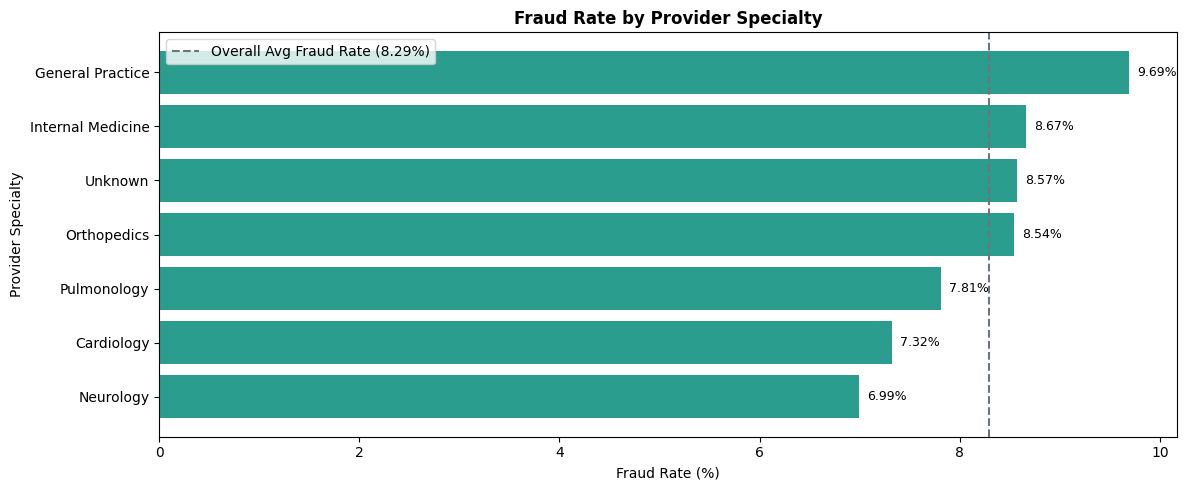

In [338]:
# Fraud rate by provider specialty chart
fraud_rate_by_chart(
    fraud_by_provider_specialty,
    "Provider_Specialty", 
    "Fraud Rate by Provider Specialty"
)

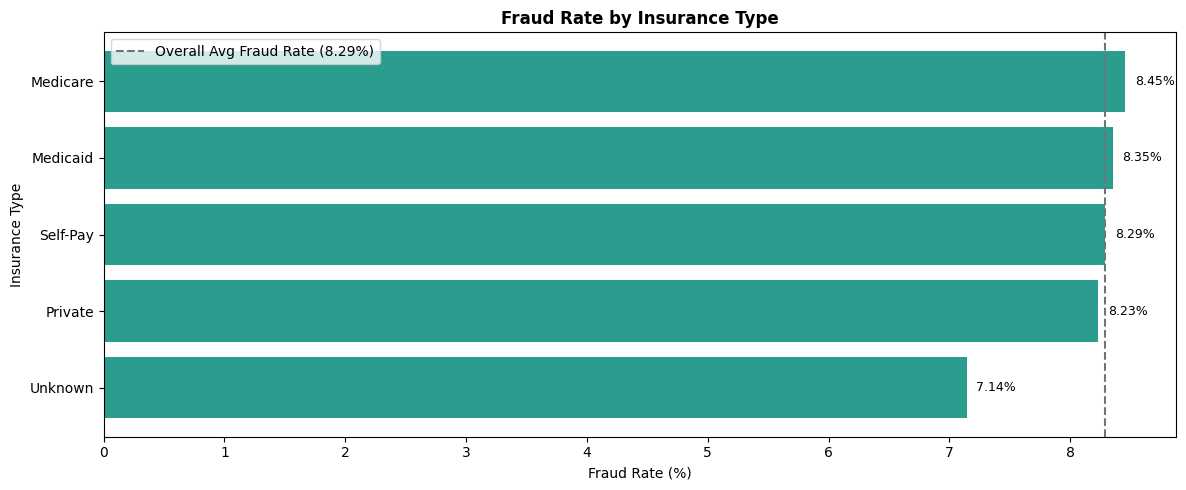

In [339]:
# Fraud rate by insurance type chart
fraud_rate_by_chart(
    fraud_by_insurance_type,
    "Insurance_Type", 
    "Fraud Rate by Insurance Type"
)

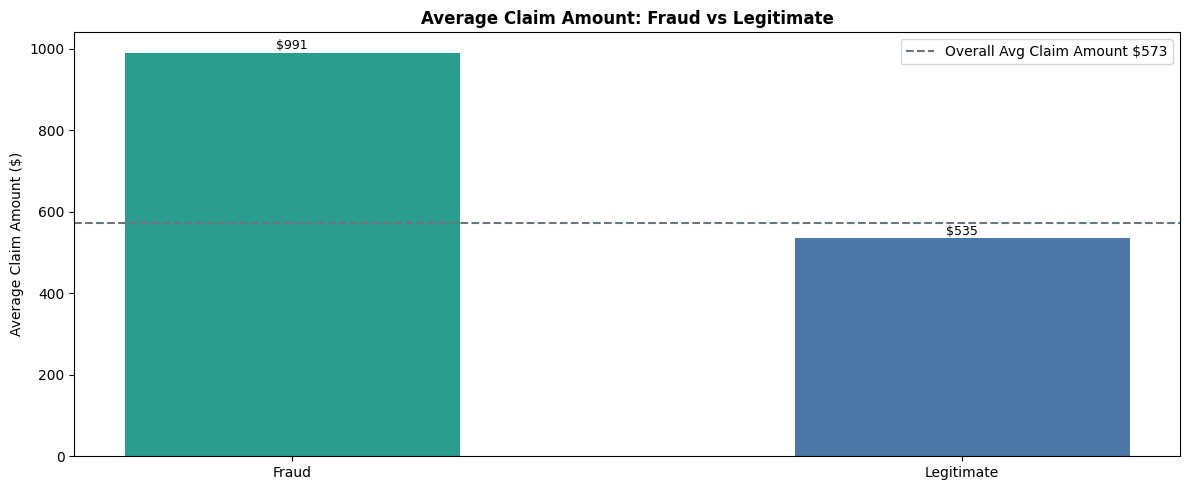

In [ ]:
# Claims averages - fraud vs legitimate chart
plt.figure(figsize=(12, 5))

bar_colours = ["#2A9D8F", "#4C78A8"] 
bars = plt.bar(
    claims_avgs["Fraud_Label"],
    claims_avgs["Avg_Claim_Amount"],
    color=bar_colours,
    width=0.5
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 8,                         
        f"${height:,.0f}",
        ha="center", fontsize=9
    )

plt.axhline(
    y=avg_claim_count,
    linestyle="--",
    label=f"Overall Avg Claim Amount (${avg_claim_count:.0f})",
    color="#6C757D"
)

plt.legend()
plt.title("Average Claim Amount: Fraud vs Legitimate", fontweight="bold")
plt.ylabel("Average Claim Amount ($)")
plt.tight_layout()
plt.show()

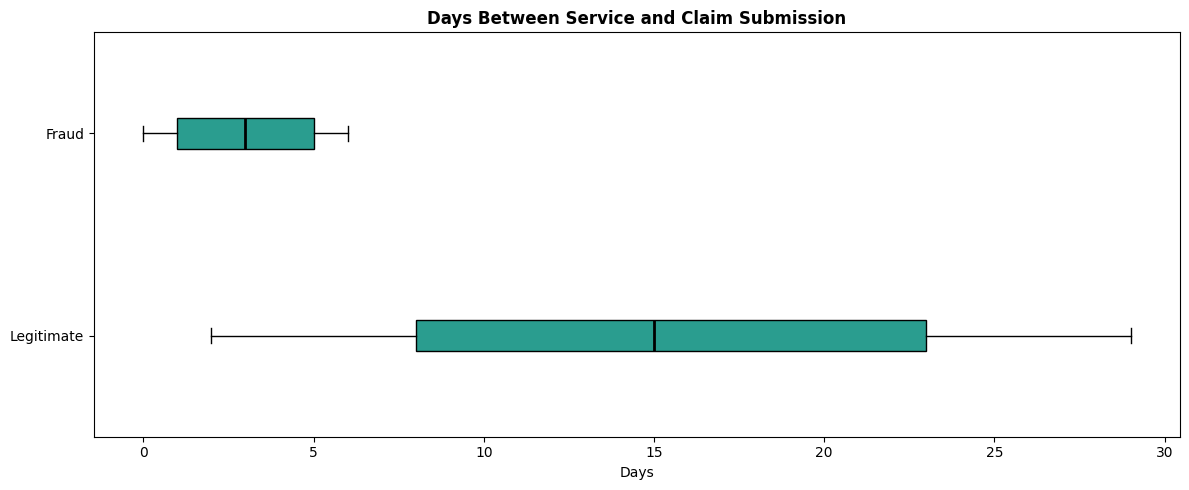

In [341]:
# Days to submit - fraud vs legitimate chart
legit_days = df[df["Fraud_Label"] == "Legitimate"]["Days_Between_Service_and_Claim"]
fraud_days = df[df["Fraud_Label"] == "Fraud"]["Days_Between_Service_and_Claim"]

plt.figure(figsize=(12, 5))

plt.boxplot(
    [legit_days, fraud_days],
    tick_labels=["Legitimate", "Fraud"],
    vert=False,
    patch_artist=True,
    boxprops=dict(
        facecolor="#2A9D8F"
    ),
    medianprops=dict(
        color="black",
        linewidth=2
    )
)

plt.xlabel("Days")
plt.title("Days Between Service and Claim Submission", fontweight="bold")
plt.tight_layout()
plt.show()

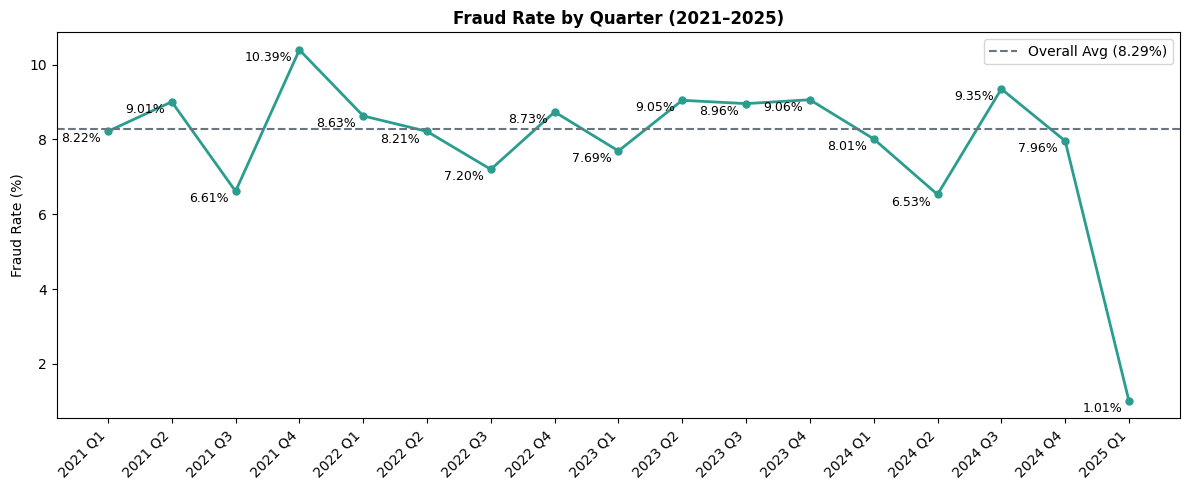

In [357]:
# Fraud quarterly chart
fraud_quarterly["Period"] = (
    fraud_quarterly["Year"].astype(str) 
    + " " 
    + fraud_quarterly["Quarter"]
)

plt.figure(figsize=(12, 5))

plt.plot(
    fraud_quarterly["Period"],
    fraud_quarterly["Fraud_Rate"] * 100,
    marker="o",
    color="#2A9D8F",
    linewidth=2,
    markersize=5
)

for x, y in zip(fraud_quarterly["Period"], fraud_quarterly["Fraud_Rate"] * 100):
    plt.annotate(
        f"{y:.2f}%",
        xy=(x, y),
        xytext=(-5, -8),        
        textcoords="offset points",
        ha="right", fontsize=9
    )
    
plt.axhline(
    fraud_rate * 100,
    color="#6C757D",
    linestyle="--",
    label=f"Overall Avg ({fraud_rate:.2%})"
)
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Quarter (2021–2025)", fontweight="bold")
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()